In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


In [6]:
steam_data_path = "data/steam-games-dataset/"

def read_multi(fname, col):
    with open(steam_data_path + fname, encoding="cp1252") as f:
        rows = (line.rstrip("\r\n").split(",") for line in f)
        return pd.DataFrame(
            [(int(r[0]), v.strip()) for r in rows for v in r[1:] if v.strip()],
            columns=["appid", col],
        )

application_info = pd.read_csv(steam_data_path + "applicationInformation.csv", encoding="cp1252")
application_developers = read_multi("applicationDevelopers.csv", "developer")
application_genres = read_multi("applicationGenres.csv", "genre")
application_packages = read_multi("applicationPackages.csv", "packageid")
application_publishers = read_multi("applicationPublishers.csv", "publisher")
application_supported_languages = read_multi("applicationSupportedlanguages.csv", "language")
application_tags = read_multi("applicationTags.csv", "tag")

In [7]:
application_info.head(10)

,appid,type,name,releasedate,freetoplay
0,578080,game,PLAYERUNKNOWN'S BATTLEGROUNDS,21-Dec-17,0.0
1,570,game,Dota 2,9-Jul-13,1.0
2,730,game,Counter-Strike: Global Offensive,21-Aug-12,1.0
3,622590,NaN,PLAYERUNKNOWN'S BATTLEGROUNDS (Test Server),NaN,NaN
4,359550,game,Tom Clancy's Rainbow Six Siege,1-Dec-15,0.0
5,271590,game,Grand Theft Auto V,13-Apr-15,0.0
6,238960,game,Path of Exile,23-Oct-13,1.0
7,230410,game,Warframe,25-Mar-13,1.0
8,440,game,Team Fortress 2,10-Oct-07,1.0
9,252950,game,Rocket League,7-Jul-15,0.0


In [8]:
application_developers.head(10)

,appid,developer
0,578080,PUBG Corporation
1,570,Valve
2,730,Valve
3,730,Hidden Path Entertainment
4,359550,Ubisoft Montreal
5,271590,Rockstar North
6,238960,Grinding Gear Games
7,230410,Digital Extremes
8,440,Valve
9,252950,"""Psyonix"


In [9]:
application_genres.head(10)

,appid,genre
0,578080,Action
1,578080,Adventure
2,578080,Massively Multiplayer
3,570,Action
4,570,Free to Play
5,570,Strategy
6,730,Action
7,730,Free to Play
8,359550,Action
9,271590,Action


In [10]:
application_packages.head(10)

,appid,packageid
0,578080,147588
1,578080,349553
2,570,197846
3,570,330209
4,730,329385
5,730,298963
6,730,54029
7,359550,88521
8,359550,337582
9,359550,337569


In [11]:
application_tags.head(10)

,appid,tag
0,578080,Survival
1,578080,Shooter
2,578080,Multiplayer
3,578080,PvP
4,578080,FPS
5,578080,Third-Person Shooter
6,578080,Action
7,578080,Online Co-Op
8,578080,Tactical
9,578080,Battle Royale


In [12]:
application_publishers.head(10)

,appid,publisher
0,578080,PUBG Corporation
1,570,Valve
2,730,Valve
3,359550,Ubisoft
4,271590,Rockstar Games
5,238960,Grinding Gear Games
6,230410,Digital Extremes
7,440,Valve
8,252950,"""Psyonix"
9,252950,"Inc."""


In [13]:
application_supported_languages.head(10)

,appid,language
0,578080,English
1,578080,Korean
2,578080,Simplified Chinese
3,578080,French
4,578080,German
5,578080,Spanish - Spain
6,578080,Arabic
7,578080,Japanese
8,578080,Polish
9,578080,Portuguese


In [14]:
def find_game_ccu_file(appid):
    path1 = "PlayerCountHistoryPart1/"
    path2 = "PlayerCountHistoryPart2/"
    try:
        with open(steam_data_path + path1 + f"{appid}.csv", encoding="cp1252") as f:
            return steam_data_path + path1 + f"{appid}.csv"
    except FileNotFoundError:
        try:
            with open(steam_data_path + path2 + f"{appid}.csv", encoding="cp1252") as f:
                return steam_data_path + path2 + f"{appid}.csv"
        except FileNotFoundError:
            pass


In [22]:
game1_id = 578080
game1_file = find_game_ccu_file(game1_id)
game1_ccu = pd.read_csv(f"{game1_file}", parse_dates=["Time"], index_col="Time")

In [23]:
game1_ccu.head(10)

,Playercount
Time,
2017-12-14 00:00:00,321619.0
2017-12-14 00:05:00,314635.0
2017-12-14 00:10:00,312391.0
2017-12-14 00:15:00,312993.0
2017-12-14 00:20:00,316011.0
2017-12-14 00:25:00,320876.0
2017-12-14 00:30:00,325511.0
2017-12-14 00:35:00,330815.0
2017-12-14 00:40:00,336724.0


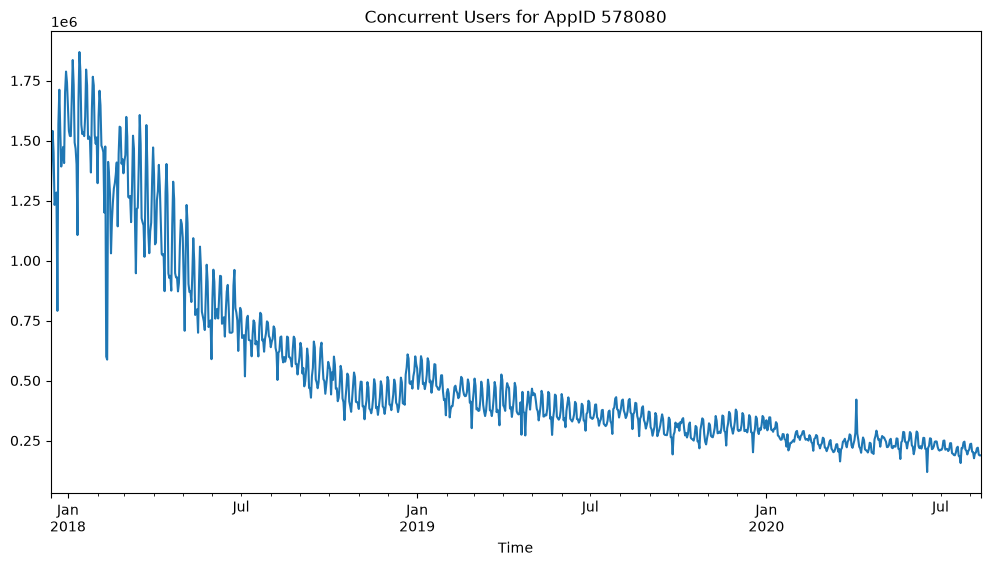

In [24]:
plot = (game1_ccu["Playercount"].resample("D").mean()
        .plot(title=f"Concurrent Users for AppID {game1_id}", figsize=(12, 6)))

In [25]:
game2_id = 292030
game2_file = find_game_ccu_file(game2_id)
game2_ccu = pd.read_csv(f"{game2_file}", parse_dates=["Time"], index_col="Time")

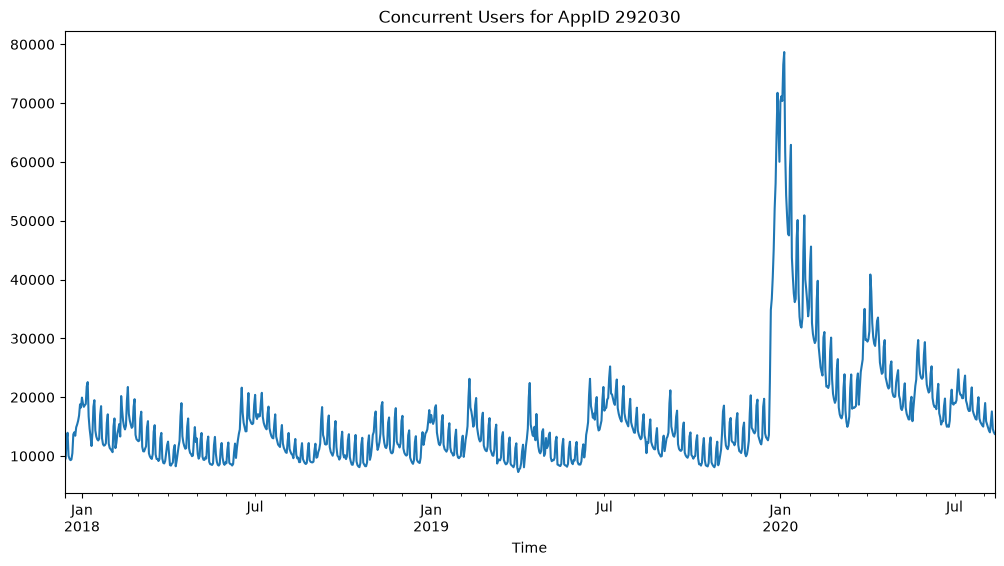

In [28]:
plot = (game2_ccu["Playercount"].resample("D").mean()
        .plot(title=f"Concurrent Users for AppID {game2_id}", figsize=(12, 6)))

In [32]:
game3_id = 252490
game3_file = find_game_ccu_file(game3_id)
game3_ccu = pd.read_csv(f"{game3_file}", parse_dates=["Time"], index_col="Time")

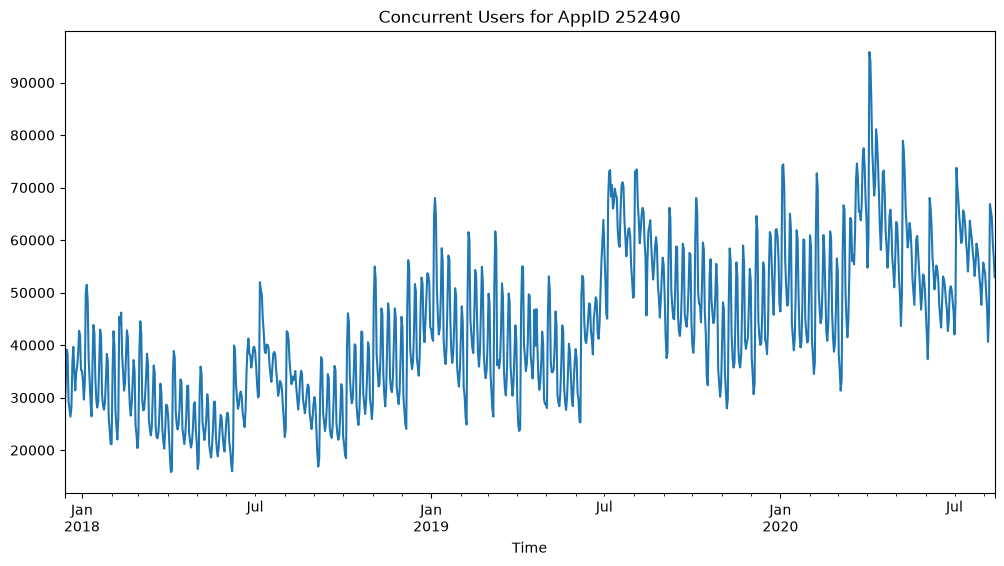

In [33]:
plot = (game3_ccu["Playercount"].resample("D").mean()
        .plot(title=f"Concurrent Users for AppID {game3_id}", figsize=(12, 6)))

In [34]:
game4_id = 570
game4_file = find_game_ccu_file(game4_id)
game4_ccu = pd.read_csv(f"{game4_file}", parse_dates=["Time"], index_col="Time")

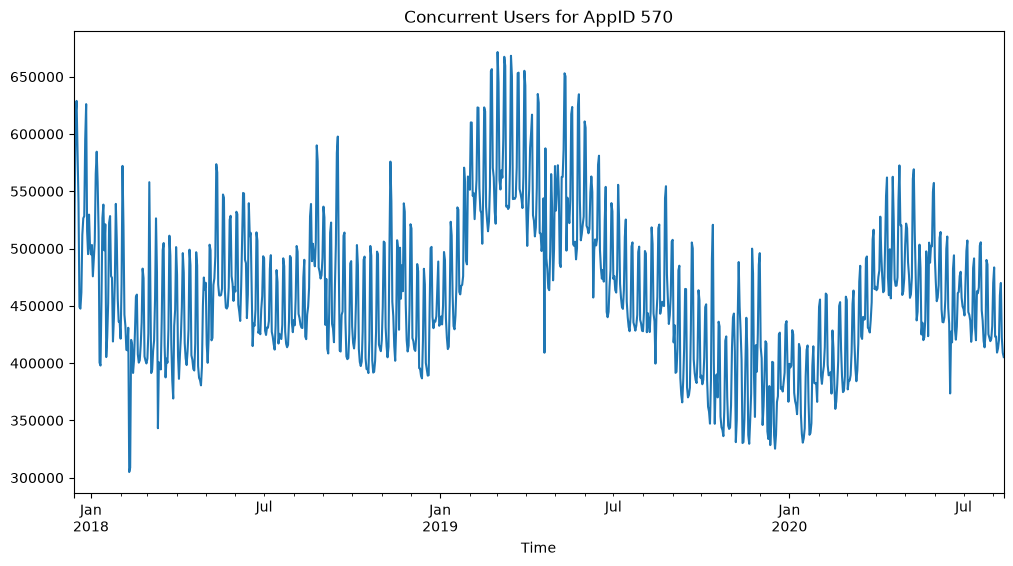

In [35]:
plot = (game4_ccu["Playercount"].resample("D").mean()
        .plot(title=f"Concurrent Users for AppID {game4_id}", figsize=(12, 6)))

In [45]:
sg_data_path = "data/sullygnome/"
peak_viewers_2020 = pd.read_csv(sg_data_path + "peakviewers_2020.csv", index_col="name")


In [46]:
matching_games = peak_viewers_2020.merge(application_info, left_index=True, right_on="name", how="left")

In [53]:
matching_games = matching_games.dropna()
matching_games.shape

(259, 18)

<Axes: title={'center': 'Counter-Strike: Global Offensive (appid 730): Steam CCU vs Twitch'}, ylabel='Steam concurrent players'>

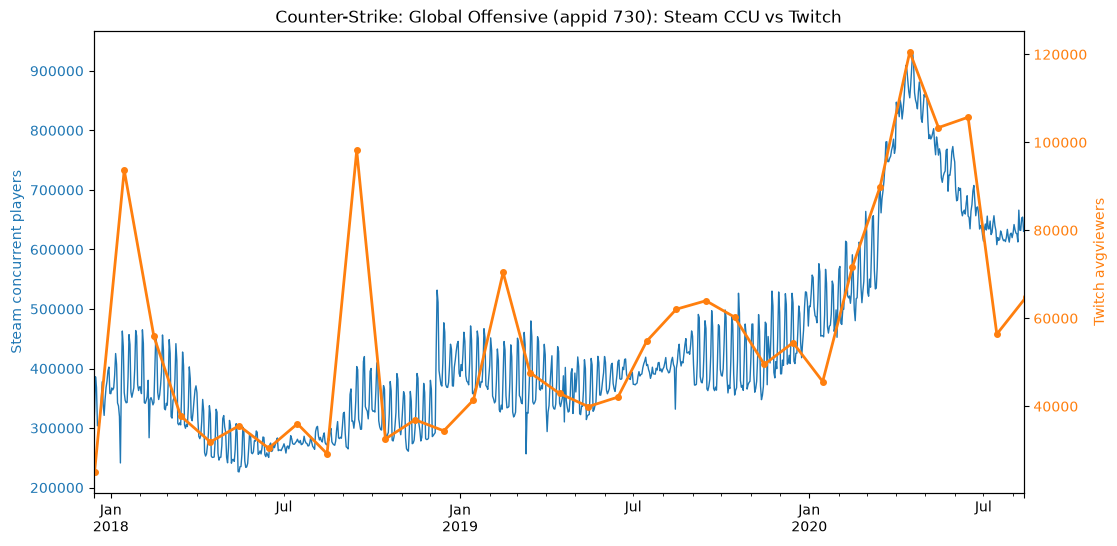

In [6]:
TW = pd.read_csv("data/sullygnome/twitch_monthly_by_appid.csv", parse_dates=["month"])

def ccu_path(appid):
    for part in ("PlayerCountHistoryPart1", "PlayerCountHistoryPart2"):
        p = f"data/steam-games-dataset/{part}/{appid}.csv"
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"no CCU history for appid {appid}")

def plot_game(appid, metric="avgviewers", ax=None):
    ccu = pd.read_csv(ccu_path(appid), parse_dates=["Time"], index_col="Time")["Playercount"]
    tw = TW[TW["appid"] == appid].set_index("month")[metric].sort_index()
    name = TW.loc[TW["appid"] == appid, "name_steam"].iloc[0]

    ax = ax or plt.subplots(figsize=(12, 6))[1]
    ccu.resample("D").mean().plot(ax=ax, color="tab:blue", lw=1, label="Steam CCU (daily mean)")
    ax.set_ylabel("Steam concurrent players", color="tab:blue")
    ax.tick_params(axis="y", labelcolor="tab:blue")
    ax.set_xlabel("")

    ax2 = ax.twinx()
    ax2.plot(tw.index + pd.Timedelta(days=14), tw.values,      # marker sits mid-month
             color="tab:orange", lw=2, marker="o", ms=4, label=f"Twitch {metric} (monthly)")
    ax2.set_ylabel(f"Twitch {metric}", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")
    ax2.set_xlim(ax.get_xlim())                                # clip Twitch to CCU window

    ax.set_title(f"{name} (appid {appid}): Steam CCU vs Twitch")
    return ax

plot_game(730)